## Task-D: Collinear features and their effect on linear models

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('task_d.csv')

In [3]:
data.head()

,x,y,z,x*x,2*y,2*z+3*x*x,w,target
0,-0.581066,0.841837,-1.012978,-0.604025,0.841837,-0.665927,-0.536277,0
1,-0.894309,-0.207835,-1.012978,-0.883052,-0.207835,-0.917054,-0.522364,0
2,-1.207552,0.212034,-1.082312,-1.150918,0.212034,-1.166507,0.205738,0
3,-1.364174,0.002099,-0.943643,-1.280666,0.002099,-1.266540,-0.665720,0
4,-0.737687,1.051772,-1.012978,-0.744934,1.051772,-0.792746,-0.735054,0


In [4]:
data["target"].value_counts()

1    50
0    50
Name: target, dtype: int64

In [5]:
X = data.drop(['target'], axis=1)
Y = data['target']

In [6]:
X.shape

(100, 7)

### Doing perturbation test to check the presence of collinearity  

#### Task: 1 Logistic Regression
<pre>


1. <b>Finding the Correlation between the features</b>
    a. check the correlation between the features
    b. plot heat map of correlation matrix using seaborn heatmap
2. <b>Finding the best model for the given data</b>
    a. Train Logistic regression on data(X,Y) that we have created in the above cell
    b. Find the best hyper prameter alpha with hyper parameter tuning using k-fold cross validation (grid search CV or         
    random search CV make sure you choose the alpha in log space)
    c. Creat a new Logistic regression with the best alpha
    (search for how to get the best hyper parameter value), name the best model as 'best_model'
    
3. <b>Getting the weights with the original data</b>
    a. train the 'best_model' with X, Y
    b. Check the accuracy of the model 'best_model_accuracy'
    c. Get the weights W using best_model.coef_

4. <b>Modifying original data</b>
    a. Add a noise(order of 10^-2) to each element of X 
    and get the new data set X' (X' = X + e)
    b. Train the same 'best_model' with data (X', Y)
    c. Check the accuracy of the model 'best_model_accuracy_edited'
    d. Get the weights W' using best_model.coef_
    
5. <b> Checking deviations in metric and weights </b>
    a. find the difference between 'best_model_accuracy_edited' and 'best_model_accuracy'
    b. find the absolute change between each value of W and W' ==> |(W-W')|
    c. print the top 4 features which have higher % change in weights 
    compare to the other feature

</pre>

#### Task: 2 Linear SVM

<pre>
1. Do the same steps (2, 3, 4, 5) we have done in the above task 1.
</pre>

<strong><font color='red'>Do write the observations based on the results you get from the deviations of weights in both Logistic Regression and linear SVM</font></strong>

## 1.1 Finding the Correlation between the features

                  x         y         z       x*x       2*y  2*z+3*x*x  \
x          1.000000 -0.205926  0.812458  0.997947 -0.205926   0.996252   
y         -0.205926  1.000000 -0.602663 -0.209289  1.000000  -0.261123   
z          0.812458 -0.602663  1.000000  0.807137 -0.602663   0.847163   
x*x        0.997947 -0.209289  0.807137  1.000000 -0.209289   0.997457   
2*y       -0.205926  1.000000 -0.602663 -0.209289  1.000000  -0.261123   
2*z+3*x*x  0.996252 -0.261123  0.847163  0.997457 -0.261123   1.000000   
w          0.583277 -0.401790  0.674486  0.583803 -0.401790   0.606860   
target     0.728290 -0.690684  0.969990  0.719570 -0.690684   0.764729   

                  w    target  
x          0.583277  0.728290  
y         -0.401790 -0.690684  
z          0.674486  0.969990  
x*x        0.583803  0.719570  
2*y       -0.401790 -0.690684  
2*z+3*x*x  0.606860  0.764729  
w          1.000000  0.641750  
target     0.641750  1.000000  


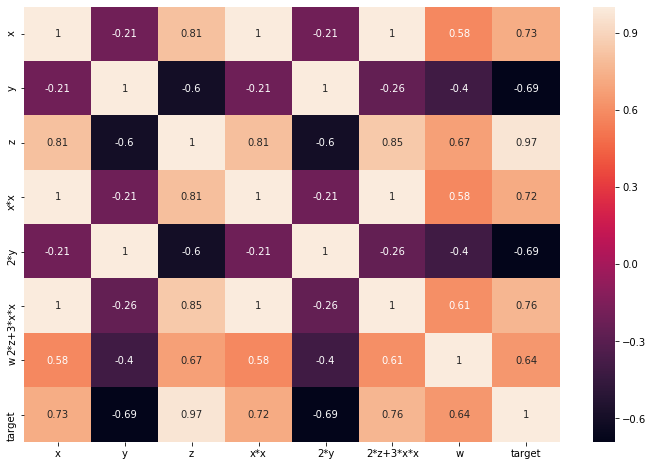

In [7]:
corr = data.corr()
print(corr)
fig = plt.subplots(figsize = (12,8))
sns.heatmap(corr, annot = True)

## 1.2 Finding the best model for the given data

In [8]:
logistic_model = SGDClassifier(eta0=0.0001, loss='log', learning_rate='constant')


parameters = {'alpha':[0.001,0.05,0.01,0.1,0.5,1,5,10,50,100]}
clf = GridSearchCV(logistic_model, parameters, cv=3, scoring='accuracy',return_train_score=True)
clf.fit(X, Y)

GridSearchCV(cv=3, error_score='raise-deprecating',
             estimator=SGDClassifier(alpha=0.0001, average=False,
                                     class_weight=None, early_stopping=False,
                                     epsilon=0.1, eta0=0.0001,
                                     fit_intercept=True, l1_ratio=0.15,
                                     learning_rate='constant', loss='log',
                                     max_iter=1000, n_iter_no_change=5,
                                     n_jobs=None, penalty='l2', power_t=0.5,
                                     random_state=None, shuffle=True, tol=0.001,
                                     validation_fraction=0.1, verbose=0,
                                     warm_start=False),
             iid='warn', n_jobs=None,
             param_grid={'alpha': [0.001, 0.05, 0.01, 0.1, 0.5, 1, 5, 10, 50,
                                   100]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
  

In [9]:
# using best_params to get the best alpha value

print(clf.best_params_['alpha'])

0.001


In [10]:
best_model_lr = SGDClassifier(alpha=0.001,eta0=0.0001, loss='log', learning_rate='constant')
best_model_lr.fit(X,Y)

SGDClassifier(alpha=0.001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='log', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=None, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=0, warm_start=False)

## 1.3 Getting the weights with the original data

In [11]:
z= best_model_lr.predict(X)
from sklearn.metrics import accuracy_score
best_model_accuracy=accuracy_score(Y, z, normalize=False)
best_model_accuracy

100

In [12]:
'''
# this function will return the predicted output

def batch_predict(clf, data):
    # roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
    # not the predicted outputs

    y_data_pred = []
    tr_loop = data.shape[0] - data.shape[0]%1000
    # consider you X_tr shape is 49041, then your tr_loop will be 49041 - 49041%1000 = 49000
    # in this for loop we will iterate unti the last 1000 multiplier
    for i in range(0, tr_loop, 1000):
        y_data_pred.extend(clf.predict_proba(data[i:i+1000])[:,1])
    # we will be predicting for the last data points
    if data.shape[0]%1000 !=0:
        y_data_pred.extend(clf.predict_proba(data[tr_loop:])[:,1])
    
    predictions = []
    for i in y_data_pred:
        if i>= 0.5:
            predictions.append(1)
        else:
            predictions.append(0)
            
    return predictions 
    
y = batch_predict(best_model,X)



'''

'\n# this function will return the predicted output\n\ndef batch_predict(clf, data):\n    # roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class\n    # not the predicted outputs\n\n    y_data_pred = []\n    tr_loop = data.shape[0] - data.shape[0]%1000\n    # consider you X_tr shape is 49041, then your tr_loop will be 49041 - 49041%1000 = 49000\n    # in this for loop we will iterate unti the last 1000 multiplier\n    for i in range(0, tr_loop, 1000):\n        y_data_pred.extend(clf.predict_proba(data[i:i+1000])[:,1])\n    # we will be predicting for the last data points\n    if data.shape[0]%1000 !=0:\n        y_data_pred.extend(clf.predict_proba(data[tr_loop:])[:,1])\n    \n    predictions = []\n    for i in y_data_pred:\n        if i>= 0.5:\n            predictions.append(1)\n        else:\n            predictions.append(0)\n            \n    return predictions \n    \ny = batch_predict(best_model,X)\n\n\n\n'

In [18]:
W = best_model_lr.coef_
W

array([[ 0.27544326, -0.29962693,  0.41298244,  0.26958397, -0.29962693,
         0.29248833,  0.24488077]])

## 1.4 Modifying original data

In [19]:
noise = (np.random.normal(0,1,[100,7]))*0.01
#print(noise)

noisy_x = X+noise

best_model_1 = SGDClassifier(alpha=0.001,eta0=0.0001, loss='log', learning_rate='constant')
best_model_1.fit(noisy_x,Y)

a= best_model_1.predict(noisy_x)
from sklearn.metrics import accuracy_score
best_model_accuracy_edited = accuracy_score(Y, a, normalize=False)
best_model_accuracy_edited

100

In [26]:
W_noisy = best_model_1.coef_
W_noisy

array([[ 0.27513354, -0.29974305,  0.41357165,  0.26984555, -0.29952972,
         0.29199493,  0.24482374]])

## 1.5 Checking deviations in metric and weights

In [21]:
accuracy_diff = best_model_accuracy_edited - best_model_accuracy
print("The difference between both the accuracy is:",accuracy_diff)

The difference between both the accuracy is: 0


[3.09719152e-04 1.16121579e-04 5.89211249e-04 2.61584071e-04
 9.72119333e-05 4.93396826e-04 5.70265551e-05]


Text(0, 0.5, 'Difference betewen weights')

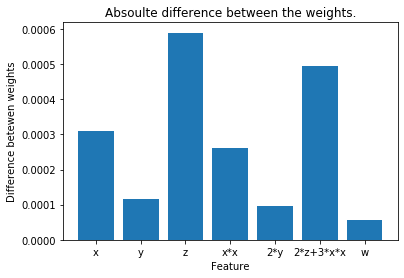

In [36]:
w_diff1= abs(W-W_noisy)[0]
print(w_diff1)

plt.bar(X.columns ,height = w_diff1)
plt.title("Absoulte difference between the weights.")
plt.xlabel("Feature")
plt.ylabel("Difference betewen weights")

In [63]:
perc = [abs(np.divide(w_diff1, W))][0]
print(perc.shape)

t = np.argsort(perc)
t = t[0,0:5]

top4f = X.columns[t]
print("4 features with most %age change in the weights are: ")
print(*top4f, sep = ", ")

(1, 7)
4 features with most %age change in the weights are: 
w, 2*y, y, x*x, x


## Observation

## 2.1 Finding the best SVM model for the given data

In [65]:
svm_model = SGDClassifier(eta0=0.0001, loss='hinge', learning_rate='constant')


parameters = {'alpha':[0.001,0.05,0.01,0.1,0.5,1,5,10,50,100]}
clf = GridSearchCV(logistic_model, parameters, cv=3, scoring='accuracy',return_train_score=True)
clf.fit(X, Y)

GridSearchCV(cv=3, error_score='raise-deprecating',
             estimator=SGDClassifier(alpha=0.0001, average=False,
                                     class_weight=None, early_stopping=False,
                                     epsilon=0.1, eta0=0.0001,
                                     fit_intercept=True, l1_ratio=0.15,
                                     learning_rate='constant', loss='log',
                                     max_iter=1000, n_iter_no_change=5,
                                     n_jobs=None, penalty='l2', power_t=0.5,
                                     random_state=None, shuffle=True, tol=0.001,
                                     validation_fraction=0.1, verbose=0,
                                     warm_start=False),
             iid='warn', n_jobs=None,
             param_grid={'alpha': [0.001, 0.05, 0.01, 0.1, 0.5, 1, 5, 10, 50,
                                   100]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
  

In [66]:
# using best_params to get the best alpha value

print(clf.best_params_['alpha'])

0.001


In [67]:
best_model_svm = SGDClassifier(alpha=0.001,eta0=0.0001, loss='hinge', learning_rate='constant')
best_model_svm.fit(X,Y)

SGDClassifier(alpha=0.001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='hinge', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=None, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=0, warm_start=False)

## 2.2 Getting the weights with the original data

In [68]:
h= best_model_svm.predict(X)
from sklearn.metrics import accuracy_score
svm_model_accuracy=accuracy_score(Y, h, normalize=False)
svm_model_accuracy

100

In [69]:
Wsvm = best_model_lr.coef_
Wsvm

array([[ 0.27544326, -0.29962693,  0.41298244,  0.26958397, -0.29962693,
         0.29248833,  0.24488077]])

## 2.3 Modifying original data

In [70]:
svm_model_1 = SGDClassifier(alpha=0.001,eta0=0.0001, loss='hinge', learning_rate='constant')
svm_model_1.fit(noisy_x,Y)

a= best_model_1.predict(noisy_x)
from sklearn.metrics import accuracy_score
svm_model_accuracy_edited = accuracy_score(Y, a, normalize=False)
svm_model_accuracy_edited

100

In [71]:
Wnoisy = svm_model_1.coef_
Wnoisy

array([[ 0.21157275, -0.27107204,  0.37890255,  0.20483095, -0.2708468 ,
         0.22940892,  0.18906443]])

## Checking deviations in metric and weights

In [72]:
accuracy_diff = svm_model_accuracy_edited - svm_model_accuracy
print("The difference between both the accuracy is:",accuracy_diff)

The difference between both the accuracy is: 0


[0.06387051 0.0285549  0.0340799  0.06475302 0.02878013 0.06307941
 0.05581634]


Text(0, 0.5, 'Difference betewen weights')

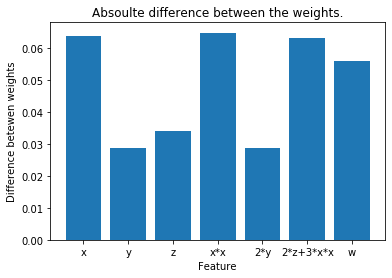

In [73]:
w_diff= abs(Wsvm-Wnoisy)[0]
print(w_diff)

plt.bar(X.columns ,height = w_diff)
plt.title("Absoulte difference between the weights.")
plt.xlabel("Feature")
plt.ylabel("Difference betewen weights")

In [74]:
perc = [abs(np.divide(w_diff1, W))][0]
print(perc.shape)

t = np.argsort(perc)
t = t[0,0:5]

top4f = X.columns[t]
print("4 features with most %age change in the weights are: ")
print(*top4f, sep = ", ")

(1, 7)
4 features with most %age change in the weights are: 
w, 2*y, y, x*x, x
